In [5]:
import numpy as np
import matplotlib.pyplot as plt 

In [8]:
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

In [17]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])            # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i]-(y[i]-y[i-1])/h[i-1])            # Right-hand side vector
    return A, B, C, D

In [16]:
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [18]:
def evaluate_spline(x, y, M, x_eval):
    n = len(x)

    # Find which interval x_eval belongs to
    for i in range(n - 1):
        if x[i] <= x_eval <= x[i + 1]:
            break

    h = x[i + 1] - x[i]

    # Cubic spline formula
    term1 = M[i] * (x[i + 1] - x_eval)**3 / (6 * h)
    term2 = M[i + 1] * (x_eval - x[i])**3 / (6 * h)
    term3 = (y[i] - M[i] * h**2 / 6) * (x[i + 1] - x_eval) / h
    term4 = (y[i + 1] - M[i + 1] * h**2 / 6) * (x_eval - x[i]) / h

    return term1 + term2 + term3 + term4

In [20]:
A, B, C, D = setup_tridiagonal_matrix(x, y)

# Solve using Thomas algorithm (use copies to avoid overwriting)
M_interior = thomas_algorithm(A.copy(), B.copy(), C.copy(), D.copy())

# Apply natural boundary conditions (M1 = Mn = 0)
M = np.zeros(len(x))
M[1:-1] = M_interior

In [22]:
x_vals = np.linspace(min(x), max(x), 100)
y_vals = [evaluate_spline(x, y, M, xi) for xi in x_vals]

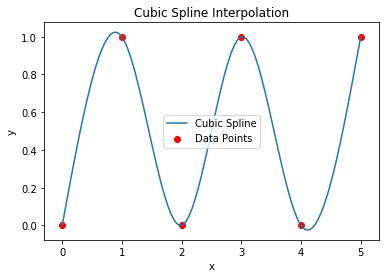

In [24]:
plt.plot(x_vals, y_vals, label="Cubic Spline")
plt.scatter(x, y, color='red', label="Data Points")

plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()